## StayEdu

## Paso 1: Instalar e importar las librerías necesarias

In [ ]:
# Instalar librerías (solo la primera vez)
!pip install pandas numpy matplotlib seaborn scikit-learn joblib streamlit pyngrok -q

# Importar las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Librerías instaladas e importadas correctamente")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 85.2 MB/s eta 0:00:00
Librerías instaladas e importadas correctamente


## Paso 2: Descargar el dataset

In [ ]:
# Dataset a utilizar → "Predict Students' Dropout and Academic Success"

!pip install opendatasets -q
import opendatasets as od

# Descargar el dataset
od.download("https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Robi Mejia
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention


100%|██████████| 87.2k/87.2k [00:00<00:00, 34.6MB/s]

## Paso 3: Cargar y explorar el dataset

In [ ]:
# Cargar el dataset
df = pd.read_csv("higher-education-predictors-of-student-retention/dataset.csv")  # Nombre del archivo

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
display(df.head())

print("\nInformación general:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

# Distribución de la variable objetivo
print("\nDistribución de la variable Target:")
print(df['Target'].value_counts())

Dimensiones del dataset: (4424, 35)

Primeras 5 filas:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000



Distribución de la variable Target:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## Paso 4: Análisis Exploratorio de Datos (EDA)

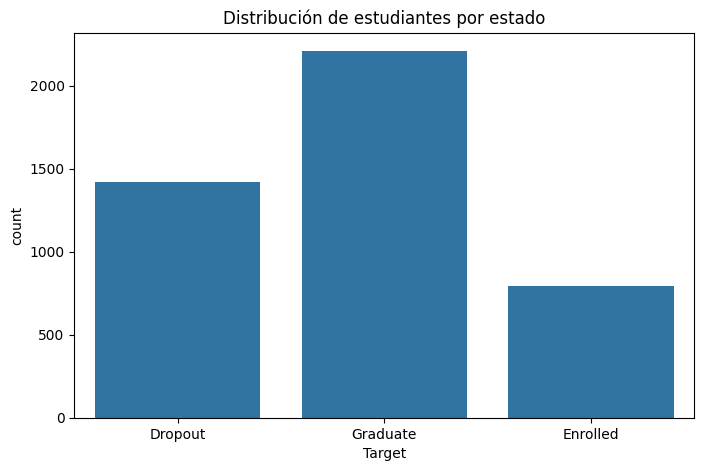

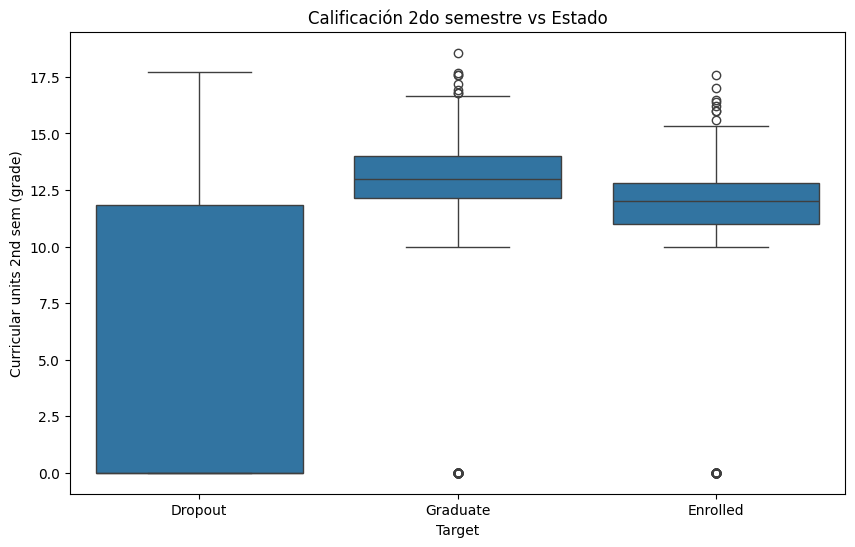

In [ ]:
# Distribución de Target
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Target')
plt.title('Distribución de estudiantes por estado')
plt.show()

# Ejemplo: relación entre calificaciones y deserción
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)')
plt.title('Calificación 2do semestre vs Estado')
plt.show()

## Paso 5: Limpieza y preprocesamiento de datos

In [ ]:
# Revisión de valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Eliminación de registros duplicados
duplicados = df.duplicated().sum()
print(f"\nRegistros duplicados encontrados: {duplicados}")
df = df.drop_duplicates()

# Codificación de la variable objetivo (Target)
# LabelEncoder ordena alfabéticamente: Dropout=0, Enrolled=1, Graduate=2
le_target = LabelEncoder()
df['Target_encoded'] = le_target.fit_transform(df['Target'])

print("\nMapeo de clases:")
for i, clase in enumerate(le_target.classes_):
    print(f"{clase} -> {i}")

# Separar variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=['Target', 'Target_encoded'])
y = df['Target_encoded']

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# División en conjunto de entrenamiento y prueba (80/20), estratificado por clase
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nEntrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")


## Paso 6: Selección de características (Feature Selection)

In [ ]:
# Se entrena un Random Forest preliminar sobre todas las variables
# únicamente para medir la importancia de cada una (no es el modelo final)
rf_importancia = RandomForestClassifier(n_estimators=200, random_state=42)
rf_importancia.fit(X_train, y_train)

importancias = pd.Series(rf_importancia.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

print("Top 15 variables más importantes:")
print(importancias.head(15))

plt.figure(figsize=(10, 6))
importancias.head(15).sort_values().plot(kind='barh')
plt.title('Importancia de variables (Top 15)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# Se seleccionan las 15 variables más relevantes para simplificar el modelo
# y facilitar el formulario de la aplicación web
N_FEATURES = 15
selected_features = importancias.head(N_FEATURES).index.tolist()
print(f"\nVariables seleccionadas ({N_FEATURES}):")
print(selected_features)

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

# Escalado de variables (se ajusta SOLO con datos de entrenamiento para evitar fuga de información)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)


## Paso 7: Entrenamiento y comparación de modelos

In [ ]:
# Se entrenan y comparan tres algoritmos de clasificación
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    resultados.append({"Modelo": nombre, "Accuracy": acc})
    print(f"{nombre}: accuracy = {acc:.4f}")

df_resultados = pd.DataFrame(resultados).sort_values(by="Accuracy", ascending=False)
print("\nComparación de modelos:")
display(df_resultados)


## Paso 8: Evaluación del mejor modelo

In [ ]:
# Se selecciona el modelo con mejor accuracy
mejor_nombre = df_resultados.iloc[0]["Modelo"]
mejor_modelo = modelos[mejor_nombre]
print(f"Mejor modelo: {mejor_nombre}")

y_pred_final = mejor_modelo.predict(X_test_scaled)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_final, target_names=le_target.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title(f'Matriz de confusión - {mejor_nombre}')
plt.show()

# Importancia de variables del modelo final (si aplica)
if hasattr(mejor_modelo, "feature_importances_"):
    imp_final = pd.Series(mejor_modelo.feature_importances_, index=selected_features)
    imp_final = imp_final.sort_values(ascending=False)
    plt.figure(figsize=(9, 5))
    imp_final.sort_values().plot(kind='barh')
    plt.title(f'Importancia de variables - {mejor_nombre}')
    plt.tight_layout()
    plt.show()


## Paso 9: Guardar el modelo con joblib

In [ ]:
# Se guardan el modelo, el scaler, el label encoder y la lista de variables
# seleccionadas, ya que la app de Streamlit necesita los cuatro para funcionar
joblib.dump(mejor_modelo, "stayedu_model.pkl")
joblib.dump(scaler, "stayedu_scaler.pkl")
joblib.dump(le_target, "stayedu_label_encoder.pkl")
joblib.dump(selected_features, "stayedu_features.pkl")

print("Archivos guardados: stayedu_model.pkl, stayedu_scaler.pkl, stayedu_label_encoder.pkl, stayedu_features.pkl")


## Paso 10: Crear la aplicación web con Streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="StayEdu", page_icon="🎓", layout="centered")

# Carga del modelo y los objetos guardados en el Paso 9
modelo = joblib.load("stayedu_model.pkl")
scaler = joblib.load("stayedu_scaler.pkl")
label_encoder = joblib.load("stayedu_label_encoder.pkl")
selected_features = joblib.load("stayedu_features.pkl")

# Etiquetas más claras para las variables más comunes de este dataset.
# Si una variable seleccionada no aparece aquí, se muestra su nombre original.
etiquetas = {
    "Curricular units 2nd sem (grade)": "Nota promedio 2do semestre",
    "Curricular units 1st sem (grade)": "Nota promedio 1er semestre",
    "Curricular units 2nd sem (approved)": "Materias aprobadas 2do semestre",
    "Curricular units 1st sem (approved)": "Materias aprobadas 1er semestre",
    "Curricular units 2nd sem (enrolled)": "Materias matriculadas 2do semestre",
    "Curricular units 1st sem (enrolled)": "Materias matriculadas 1er semestre",
    "Tuition fees up to date": "Matrícula al día (1 = Sí, 0 = No)",
    "Scholarship holder": "Tiene beca (1 = Sí, 0 = No)",
    "Debtor": "Tiene deudas pendientes (1 = Sí, 0 = No)",
    "Age at enrollment": "Edad al momento de inscribirse",
    "Admission grade": "Nota de admisión",
    "Gender": "Género (0 = Femenino, 1 = Masculino)",
    "Displaced": "Estudiante desplazado (1 = Sí, 0 = No)",
}

st.title("🎓 StayEdu")
st.write("Sistema de apoyo para estimar el riesgo de abandono académico.")

st.subheader("Datos del estudiante")

entrada = {}
with st.form("formulario_estudiante"):
    for var in selected_features:
        etiqueta = etiquetas.get(var, var)
        entrada[var] = st.number_input(etiqueta, value=0.0, step=1.0, format="%.2f")
    enviado = st.form_submit_button("Calcular riesgo")

if enviado:
    datos = pd.DataFrame([entrada])[selected_features]
    datos_escalados = scaler.transform(datos)

    prediccion = modelo.predict(datos_escalados)[0]
    probabilidades = modelo.predict_proba(datos_escalados)[0]

    clase_predicha = label_encoder.inverse_transform([prediccion])[0]

    # Se toma la probabilidad de la clase "Dropout" como referencia de riesgo
    if "Dropout" in label_encoder.classes_:
        idx_dropout = list(label_encoder.classes_).index("Dropout")
        prob_riesgo = probabilidades[idx_dropout]
    else:
        prob_riesgo = max(probabilidades)

    if prob_riesgo < 0.33:
        nivel = "Bajo"
        color = "green"
    elif prob_riesgo < 0.66:
        nivel = "Medio"
        color = "orange"
    else:
        nivel = "Alto"
        color = "red"

    st.subheader("Resultado")
    st.write(f"**Predicción del modelo:** {clase_predicha}")
    st.write(f"**Probabilidad de abandono:** {prob_riesgo * 100:.1f}%")
    st.markdown(f"**Nivel de riesgo:** :{color}[{nivel}]")

    st.subheader("Factores más relevantes (a nivel general del modelo)")
    if hasattr(modelo, "feature_importances_"):
        importancia = pd.Series(modelo.feature_importances_, index=selected_features)
        importancia = importancia.sort_values(ascending=False).head(5)
        for var, val in importancia.items():
            st.write(f"- {etiquetas.get(var, var)}")

    st.subheader("Recomendaciones generales")
    recomendaciones = {
        "Bajo": "El estudiante no muestra señales importantes de riesgo. Se recomienda dar seguimiento regular.",
        "Medio": "Se recomienda programar una tutoría de seguimiento y revisar su situación académica y económica.",
        "Alto": "Se recomienda contactar al estudiante lo antes posible y activar protocolos de apoyo académico y/o económico.",
    }
    st.info(recomendaciones[nivel])

    st.caption("Esta herramienta apoya la toma de decisiones y no reemplaza el criterio del personal académico.")


In [ ]:
# Ejecución de la app en Colab mediante un túnel de ngrok
# (requiere una cuenta gratuita en https://ngrok.com y su authtoken)
from pyngrok import ngrok

# ngrok.set_auth_token("TU_AUTHTOKEN_AQUI")  # descomentar y colocar el token
public_url = ngrok.connect(8501)
print("URL pública de la app:", public_url)

!streamlit run app.py &>/content/logs.txt &
